Exploration du Dataset final "observations_mushroom.csv" + "champignons_france_top30.csv"

In [82]:
'''
Les précédentes data explorations nous permettent de constituer le dataset final pour nos futurs modèles.

Celui-ci cible le top 30 des espèces les plus courantes en France.

Il est constitué de la fusion du dataset "champignons_france_top30.csv" et de notre dataset initial "observations_mushroom.csv" (filtré avec l'indice de confiance >= 92%)

'''

'\nLes précédentes data explorations nous permettent de constituer le dataset final pour nos futurs modèles.\n\nCelui-ci cible le top 30 des espèces les plus courantes en France.\n\nIl est constitué de la fusion du dataset "champignons_france_top30.csv" et de notre dataset initial "observations_mushroom.csv" (filtré avec l\'indice de confiance >= 92%)\n\n'

In [2]:
# import des librairies nécessaires

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Définition des chemins d'accès

rep_data = "C:\\Users\\Utilisateur\\Documents\\DataScience\\avr25cds_reconnaissance_champignons\\datasets\\" # Chemin vers le dataset "final dataset_30_species.csv"


In [ ]:
# lecture du fichier 'observations_mushroom.csv'

df = pd.read_csv(rep_data+'dataset_30_species.csv', sep =  ",")

display(df.head(5))

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\2940826543.py:3: DtypeWarning: Columns (2,5,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(rep+'dataset_30_species.csv', sep =  ",")


,image_lien,image_id,observation,label,image_url,user,date,gbif_info/kingdom,gbif_info/family,gbif_info/speciesKey,...,gbif_info/genus,gbif_info/order,thumbnail,location,gbif_info/note,gbif_info,Nom scientifique,Nom commun,Statut,Habitat typique
0,66.jpg,66,55,Trametes versicolor,http://mushroomobserver.org/images/320/66,1,2006-05-21 07:18:39,Fungi,Polyporaceae,2548311.0,...,Trametes,Polyporales,1,69.0,NaN,NaN,Trametes versicolor,Tramète versicolore,Non comestible (médicinal),Bois morts
1,67.jpg,67,56,Trametes versicolor,http://mushroomobserver.org/images/320/67,1,2006-05-21 07:18:40,Fungi,Polyporaceae,2548311.0,...,Trametes,Polyporales,0,60.0,NaN,NaN,Trametes versicolor,Tramète versicolore,Non comestible (médicinal),Bois morts
2,68.jpg,68,56,Trametes versicolor,http://mushroomobserver.org/images/320/68,1,2006-05-21 07:18:40,Fungi,Polyporaceae,2548311.0,...,Trametes,Polyporales,1,60.0,NaN,NaN,Trametes versicolor,Tramète versicolore,Non comestible (médicinal),Bois morts
3,100.jpg,100,86,Schizophyllum commune,http://mushroomobserver.org/images/320/100,1,2006-05-21 07:19:29,Fungi,Schizophyllaceae,5241128.0,...,Schizophyllum,Agaricales,1,58.0,NaN,NaN,Schizophyllum commune,Schizophylle commun,Non comestible,Bois morts
4,107.jpg,107,93,Russula virescens,http://mushroomobserver.org/images/320/107,1,2006-05-21 07:19:38,Fungi,Russulaceae,2551423.0,...,Russula,Russulales,1,53.0,NaN,NaN,Russula virescens,Russule verdoyante,Comestible,Forêts claires de feuillus


In [7]:
# apperçu des variables

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20592 entries, 0 to 20591
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   image_lien                20592 non-null  object 
 1   image_id                  20592 non-null  int64  
 2   observation               20592 non-null  object 
 3   label                     20592 non-null  object 
 4   image_url                 20592 non-null  object 
 5   user                      20592 non-null  object 
 6   date                      20592 non-null  object 
 7   gbif_info/kingdom         20592 non-null  object 
 8   gbif_info/family          20592 non-null  object 
 9   gbif_info/speciesKey      20592 non-null  float64
 10  gbif_info/rank            20592 non-null  object 
 11  gbif_info/phylum          20592 non-null  object 
 12  gbif_info/orderKey        20592 non-null  float64
 13  gbif_info/species         20592 non-null  object 
 14  gbif_i

None

In [12]:
df.shape

(20592, 37)

In [36]:
valeurs_manquantes = pd.DataFrame(df.isna().sum(), columns = ["nb_val_manquantes"])
valeurs_manquantes.loc[valeurs_manquantes["nb_val_manquantes"]!=0]

,nb_val_manquantes
location,2
gbif_info/note,20209
gbif_info,20592


count    20592.000000
mean        97.735528
std          0.444681
min         94.000000
25%         97.000000
50%         98.000000
75%         98.000000
max         98.000000
Name: gbif_info/confidence, dtype: float64

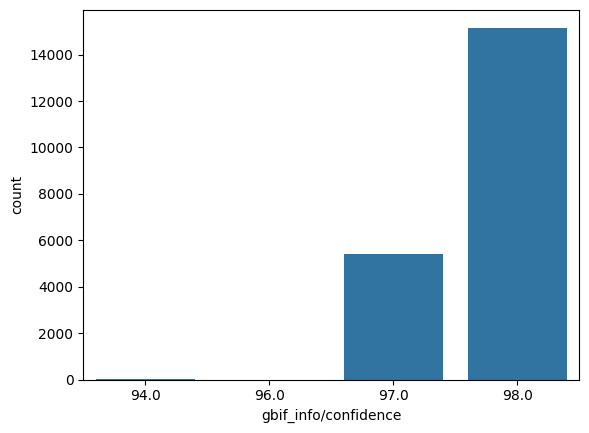

In [9]:
# Analyse de la variable de confiance dans les labellisations "gbif_info/confidence"

sns.countplot(x=df['gbif_info/confidence'])

display(df['gbif_info/confidence'].describe())

In [86]:
cols = ['gbif_info/kingdom', 'gbif_info/phylum', 'gbif_info/class', 'gbif_info/order', 'gbif_info/family', 'gbif_info/genus','gbif_info/species', 'Nom commun', 'Statut', 'Habitat typique']

In [87]:
df[cols].describe(include='object')

,gbif_info/kingdom,gbif_info/phylum,gbif_info/class,gbif_info/order,gbif_info/family,gbif_info/genus,gbif_info/species,Nom commun,Statut,Habitat typique
count,20592,20592,20592,20592,20592,20592,20592,20592,20592,20592
unique,1,1,1,7,16,20,30,30,10,25
top,Fungi,Basidiomycota,Agaricomycetes,Agaricales,Amanitaceae,Amanita,Amanita muscaria,Amanite tue-mouches,Comestible,"Forêts de bouleaux, conifères"
freq,20592,20592,20592,11769,5347,5347,3581,3581,7857,3581


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\2471047605.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ordres.values, y=ordres.index, palette='viridis')


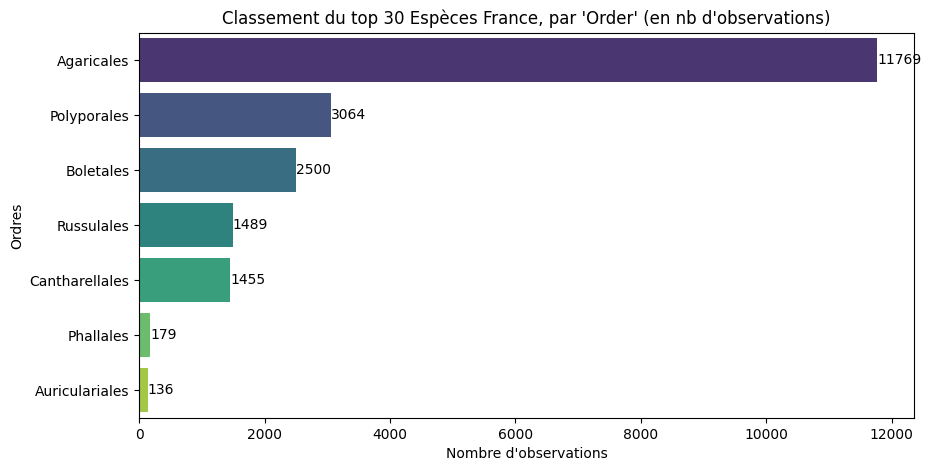

In [93]:

ordres = df['gbif_info/order'].value_counts()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=ordres.values, y=ordres.index, palette='viridis')
plt.title("Classement du top 30 Espèces France, par 'Order' (en nb d'observations)")
plt.xlabel("Nombre d'observations")
plt.ylabel("Ordres")

for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\1581028685.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=familles.values, y=familles.index, palette='viridis')


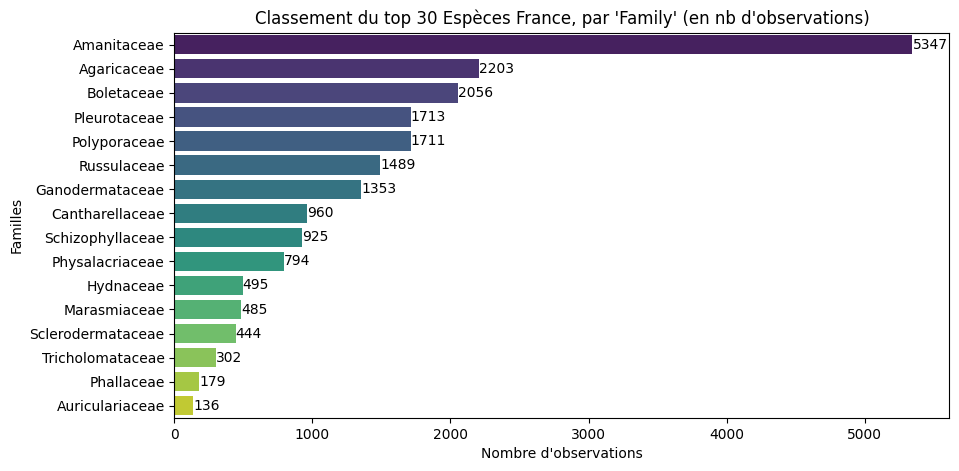

In [95]:
familles = df['gbif_info/family'].value_counts()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=familles.values, y=familles.index, palette='viridis')
plt.title("Classement du top 30 Espèces France, par 'Family' (en nb d'observations)")
plt.xlabel("Nombre d'observations")
plt.ylabel("Familles")

for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\3735532063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=genres.values, y=genres.index, palette='viridis')


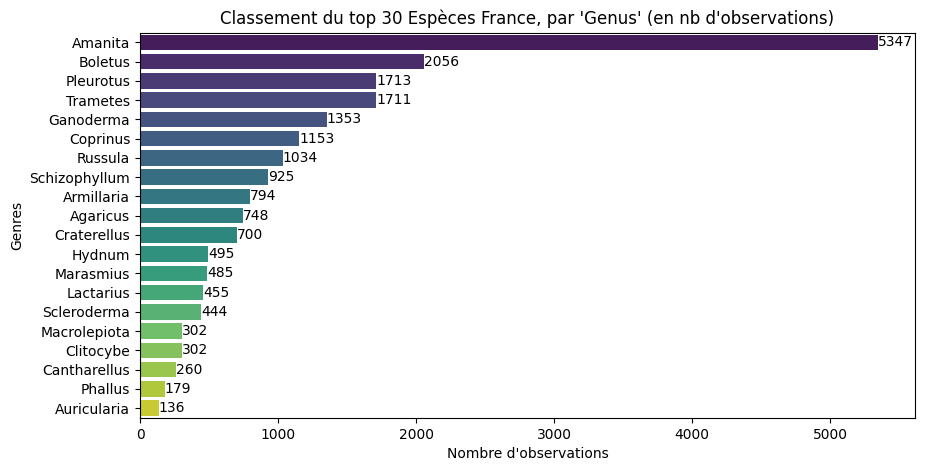

In [96]:
genres = df['gbif_info/genus'].value_counts()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=genres.values, y=genres.index, palette='viridis')
plt.title("Classement du top 30 Espèces France, par 'Genus' (en nb d'observations)")
plt.xlabel("Nombre d'observations")
plt.ylabel("Genres")


for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\63156974.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=especes.values, y=especes.index, palette='viridis')


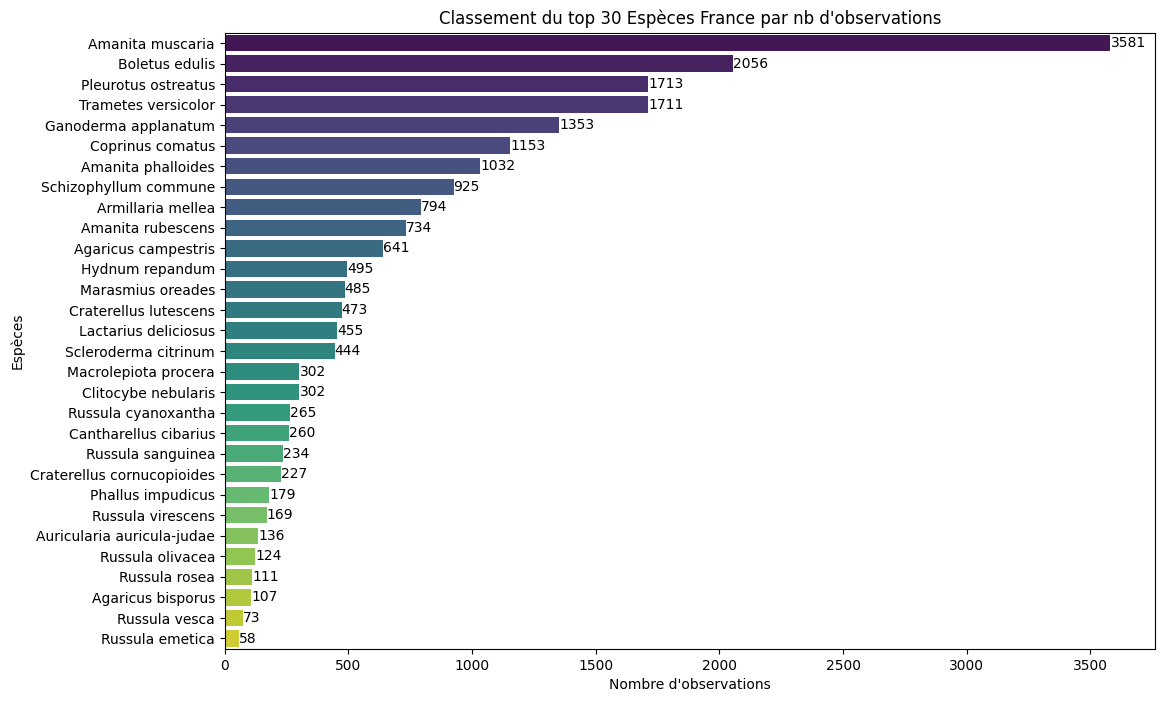

In [97]:
especes = df['gbif_info/species'].value_counts()
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=especes.values, y=especes.index, palette='viridis')
plt.title("Classement du top 30 Espèces France par nb d'observations")
plt.xlabel("Nombre d'observations")
plt.ylabel("Espèces")

for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\3266153353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=noms_communs.values, y=noms_communs.index, palette='viridis')


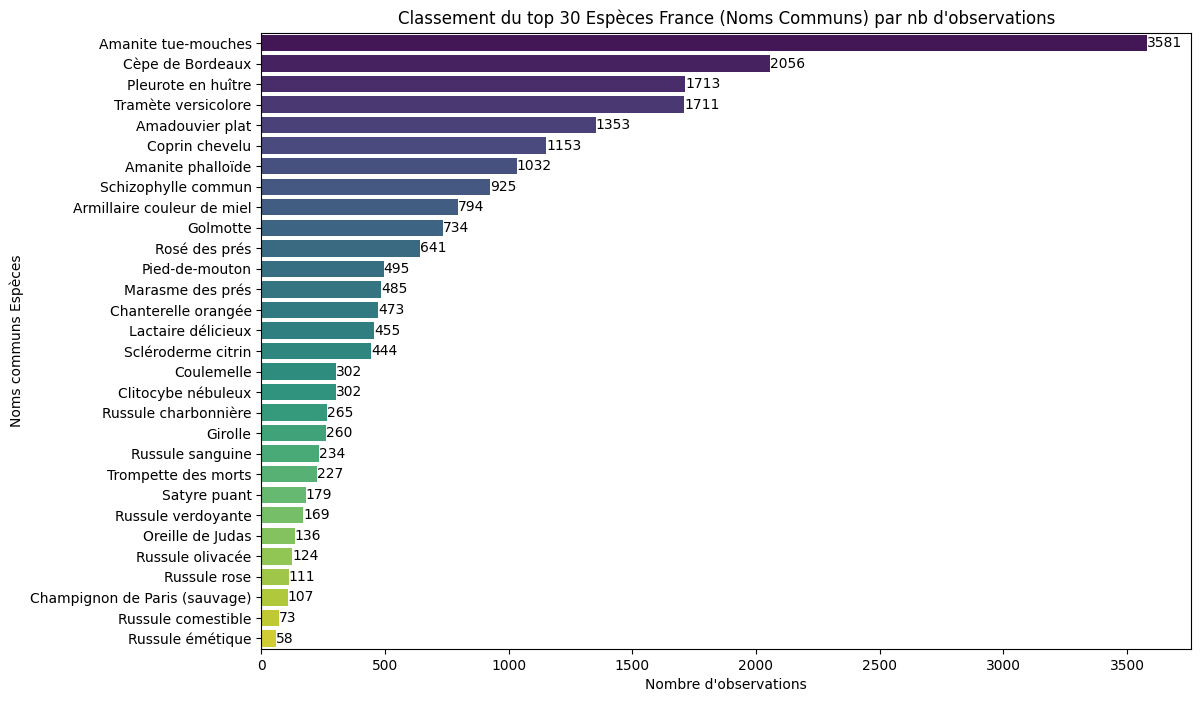

In [98]:
noms_communs = df['Nom commun'].value_counts()
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=noms_communs.values, y=noms_communs.index, palette='viridis')
plt.title("Classement du top 30 Espèces France (Noms Communs) par nb d'observations")
plt.xlabel("Nombre d'observations")
plt.ylabel("Noms communs Espèces")

for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\3811668612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=habitats.values, y=habitats.index, palette='viridis')


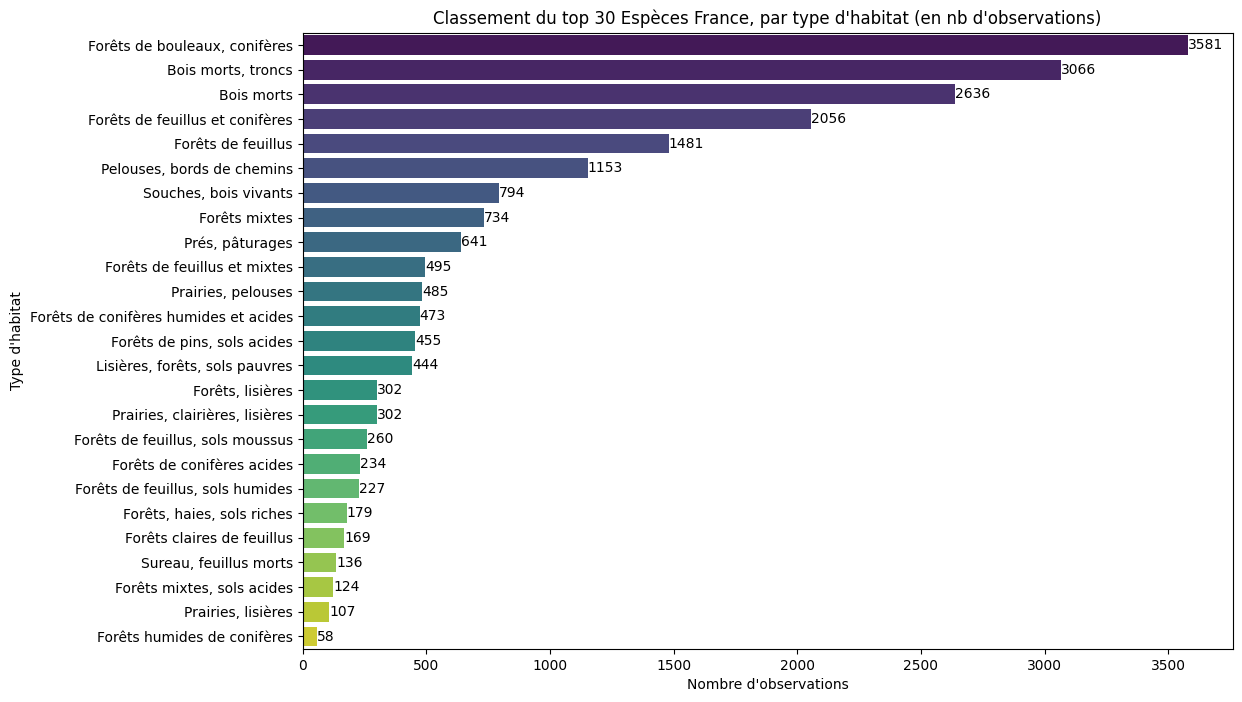

In [99]:
habitats = df['Habitat typique'].value_counts()
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=habitats.values, y=habitats.index, palette='viridis')
plt.title("Classement du top 30 Espèces France, par type d'habitat (en nb d'observations)")
plt.xlabel("Nombre d'observations")
plt.ylabel("Type d'habitat")

for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_19160\3878980542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status.values, y=status.index, palette='viridis')


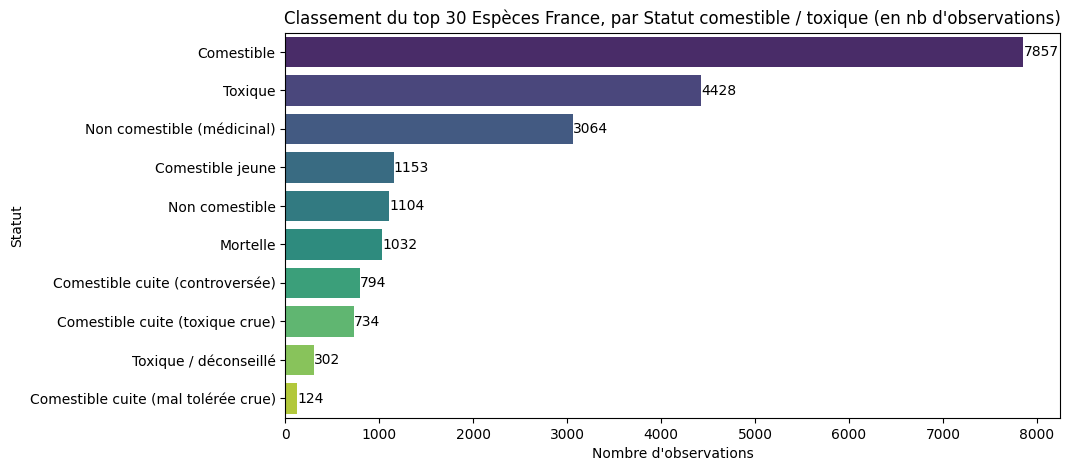

In [100]:
status = df['Statut'].value_counts()
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=status.values, y=status.index, palette='viridis')
plt.title("Classement du top 30 Espèces France, par Statut comestible / toxique (en nb d'observations)")
plt.xlabel("Nombre d'observations")
plt.ylabel("Statut")


for i in range(len(ax.containers)) :
    ax.bar_label(ax.containers[i])

plt.show()